In [6]:
# Install transformers if you haven't already:
# !pip install transformers torch

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
from transformers import pipeline
from sklearn.preprocessing import label_binarize
from sklearn.feature_extraction.text import TfidfVectorizer

warnings.filterwarnings('ignore')

In [7]:
# TF-IDF Weighted GloVe representation
def get_tfidf_glove_representation(texts, glove_dict, vector_size=100):
    print("Building TF-IDF features...")
    tfidf = TfidfVectorizer()
    tfidf.fit(texts)
    vocab = tfidf.vocabulary_
    features =[]
    
    for text in texts:
        tokens = str(text).lower().split()
        weighted_vectors = []
        weights =[]
        
        for token in tokens:
            if token in glove_dict and token in vocab:
                idx = vocab[token]
                weight = tfidf.idf_[idx]
                weighted_vectors.append(glove_dict[token] * weight)
                weights.append(weight)
                
        if len(weighted_vectors) > 0:
            vec = np.sum(weighted_vectors, axis=0) / np.sum(weights)
        else:
            vec = np.zeros(vector_size)
            
        features.append(vec)
    return np.array(features)

# Evaluation Metrics Calculator
def calculate_metrics(y_true, y_pred, y_probs, classes):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    
    # Calculate ROC-AUC (One-vs-Rest)
    y_true_bin = label_binarize(y_true, classes=classes)
    try:
        roc_auc = roc_auc_score(y_true_bin, y_probs, multi_class='ovr', average='weighted')
    except ValueError:
        roc_auc = np.nan # Fallback in case of missing classes in a tiny batch
        
    return acc, prec, rec, f1, roc_auc

In [ ]:
print("Loading Data and Custom SVM Model...")
# Use the correct file name from Task 4
df = pd.read_csv("full_dataset.csv").dropna(subset=["ground_truth"])
X = df["text"].values
y = df["ground_truth"].values

# Handle categories - fill empty ones with "General"
categories = df["subject_tag"].fillna("General").values

# Load the saved model pipeline
pipeline_data = joblib.load("sentiment_pipeline.pkl")
svm_model = pipeline_data["model"]
glove_dict = pipeline_data["glove"]

# Recreate the exact same feature extraction and split
X_glove = get_tfidf_glove_representation(X, glove_dict)

# Important: Must use exactly the same random_state and stratify to match Task 4
X_train_feat, X_test_feat, y_train, y_test, X_text_train, X_test_text = train_test_split(
    X_glove, y, X, test_size=0.20, random_state=42, stratify=y
)

# Extract test categories for the breakdown later
_, test_categories = train_test_split(categories, test_size=0.20, random_state=42, stratify=y)

print("Running Inference with Optimized SVM on Test Set...")
svm_preds = svm_model.predict(X_test_feat)
svm_probs = svm_model.predict_proba(X_test_feat)

# Attach full predictions back to the main dataframe for final export
df['SVM_Prediction'] = svm_model.predict(X_glove)

Loading Data and Custom SVM Model...
Building TF-IDF features...
Running Inference with Optimized SVM on Test Set...


In [9]:
print("Loading SOTA Model (RoBERTa) from Hugging Face...")
# top_k=None forces the pipeline to return probabilities for all 3 classes
sota_pipeline = pipeline(
    "text-classification", 
    model="cardiffnlp/twitter-roberta-base-sentiment-latest", 
    top_k=None, 
    truncation=True, 
    max_length=512
)

print("Running Inference with SOTA Model...")
sota_raw_output = sota_pipeline(X_test_text.tolist())

sota_preds = []
sota_probs =[]
model_classes = list(svm_model.classes_) # Usually ['Negative', 'Neutral', 'Positive']

for result in sota_raw_output:
    # Capitalize the Hugging Face labels (positive -> Positive) to match our ground truth
    res_dict = {res['label'].capitalize(): res['score'] for res in result}
    
    # Get highest scoring label
    best_label = max(res_dict, key=res_dict.get)
    sota_preds.append(best_label)
    
    # Build probability array strictly matching our SVM's class order
    probs_array = [res_dict.get(cls, 0.0) for cls in model_classes]
    sota_probs.append(probs_array)
    
sota_probs = np.array(sota_probs)

# Predict on entire dataset for the final CSV deliverable
all_sota_raw = sota_pipeline(X.tolist())
df['SOTA_Prediction'] = [
    max({r['label'].capitalize(): r['score'] for r in res}, 
        key={r['label'].capitalize(): r['score'] for r in res}.get) 
    for res in all_sota_raw
]

Loading SOTA Model (RoBERTa) from Hugging Face...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 11167.77it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Running Inference with SOTA Model...


In [10]:
print("Computing Overall Evaluation Metrics...")

svm_metrics = calculate_metrics(y_test, svm_preds, svm_probs, model_classes)
sota_metrics = calculate_metrics(y_test, sota_preds, sota_probs, model_classes)

results_df = pd.DataFrame([["Optimized SVM (TF-IDF GloVe)"] + list(svm_metrics),
    ["SOTA (RoBERTa Twitter)"] + list(sota_metrics)
], columns=["Model", "Accuracy", "Precision", "Recall", "F1_Score", "ROC-AUC"])

# Display the table
from IPython.display import display
display(results_df.round(4))

# Save to CSV
results_df.to_csv("sota_vs_svm_metrics.csv", index=False)

Computing Overall Evaluation Metrics...


,Model,Accuracy,Precision,Recall,F1_Score,ROC-AUC
0,Optimized SVM (TF-IDF GloVe),0.7500,0.7389,0.7500,0.7411,0.9039
1,SOTA (RoBERTa Twitter),0.8833,0.8881,0.8833,0.8841,0.9635


In [11]:
print("Computing Per-Category Breakdown (Accuracy & Macro F1)...")
cat_results =[]

# Get unique categories present in the test set
unique_cats = list(set([cat for sublist in test_categories for cat in str(sublist).split(', ')]))

for cat in unique_cats:
    if cat == "nan" or not cat: continue
        
    # Find indices where this category appears
    idx =[i for i, c in enumerate(test_categories) if cat in str(c)]
    if len(idx) == 0: continue
        
    y_test_cat = np.array(y_test)[idx]
    svm_pred_cat = np.array(svm_preds)[idx]
    sota_pred_cat = np.array(sota_preds)[idx]
    
    # Calculate metrics
    svm_acc = accuracy_score(y_test_cat, svm_pred_cat)
    svm_f1 = f1_score(y_test_cat, svm_pred_cat, average='macro', zero_division=0)
    
    sota_acc = accuracy_score(y_test_cat, sota_pred_cat)
    sota_f1 = f1_score(y_test_cat, sota_pred_cat, average='macro', zero_division=0)
    
    cat_results.append([cat, len(idx), svm_acc, svm_f1, sota_acc, sota_f1])
    
cat_df = pd.DataFrame(cat_results, columns=["Category", "Support", "Opt_Acc", "Opt_F1", "SOTA_Acc", "SOTA_F1"])

# Display the breakdown
display(cat_df.round(4))
cat_df.to_csv("category_breakdown.csv", index=False)

Computing Per-Category Breakdown (Accuracy & Macro F1)...


,Category,Support,Opt_Acc,Opt_F1,SOTA_Acc,SOTA_F1
0,Customer Service,24,0.9167,0.8418,0.9167,0.8958
1,General,17,0.5294,0.5037,0.8235,0.8278
2,Loans,8,0.8750,0.8857,0.7500,0.7302
3,Digital Banking,14,0.7143,0.6667,0.9286,0.9221


Generating Visualizations...


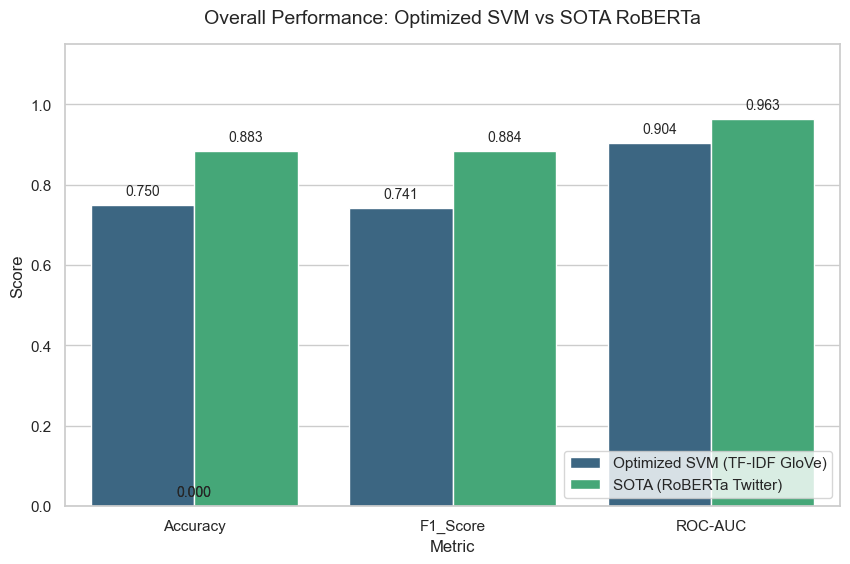

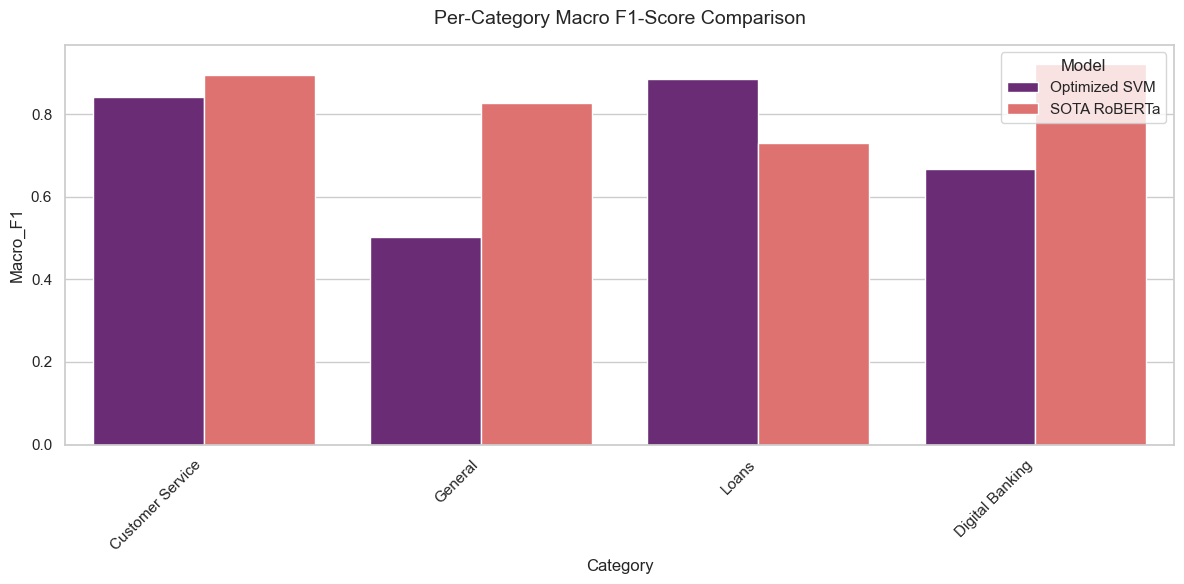

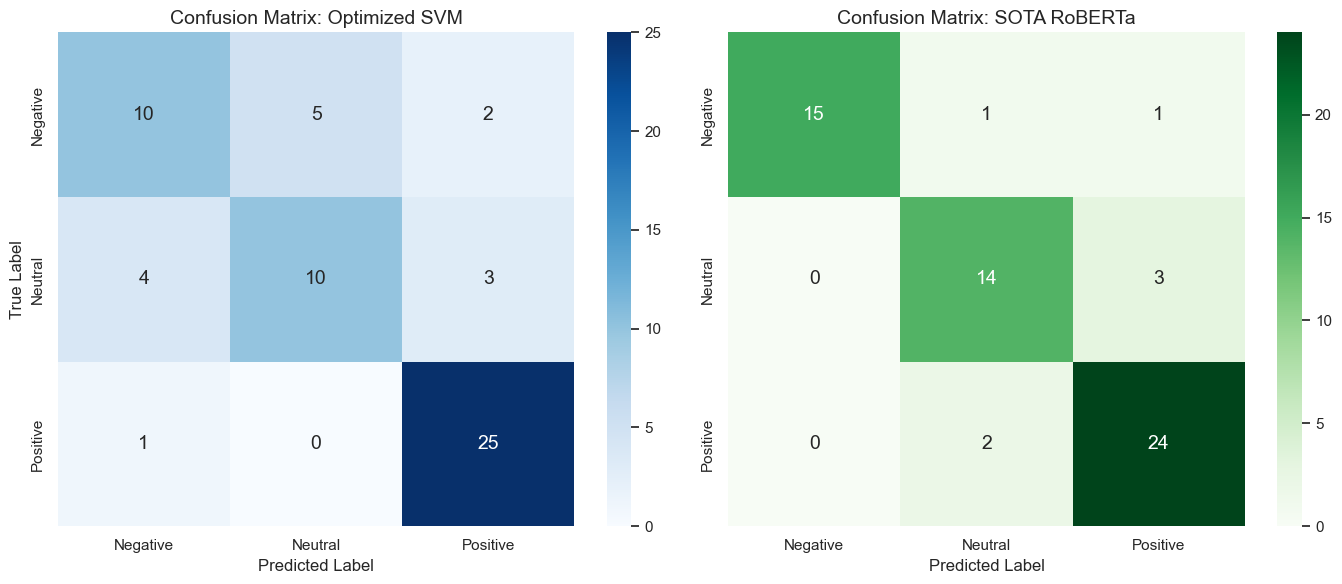

In [13]:
print("Generating Visualizations...")
sns.set_theme(style="whitegrid")

# Plot 1: Overall Metrics Comparison
metrics_to_plot =["Accuracy", "F1_Score", "ROC-AUC"]
df_melted = results_df.melt(id_vars="Model", value_vars=metrics_to_plot, var_name="Metric", value_name="Score")

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_melted, x="Metric", y="Score", hue="Model", palette="viridis")
plt.ylim(0, 1.15)
plt.title("Overall Performance: Optimized SVM vs SOTA RoBERTa", fontsize=14, pad=15)
plt.legend(loc='lower right')

# Add values on top of bars
for p in ax.patches:
    ax.annotate(f"{p.get_height():.3f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10, xytext=(0, 5), textcoords='offset points')
plt.savefig("plot_overall_comparison.png", bbox_inches='tight')
plt.show()

# Plot 2: Per-Category F1 Score
plt.figure(figsize=(12, 6))
df_cat_melted = cat_df.melt(id_vars="Category", value_vars=["Opt_F1", "SOTA_F1"], var_name="Model", value_name="Macro_F1")
# Rename for cleaner legend
df_cat_melted['Model'] = df_cat_melted['Model'].map({"Opt_F1": "Optimized SVM", "SOTA_F1": "SOTA RoBERTa"})

sns.barplot(data=df_cat_melted, x="Category", y="Macro_F1", hue="Model", palette="magma")
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.title("Per-Category Macro F1-Score Comparison", fontsize=14, pad=15)
plt.tight_layout()
plt.savefig("plot_category_breakdown.png")
plt.show()

# Plot 3: Side-by-Side Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(confusion_matrix(y_test, svm_preds, labels=model_classes), 
            annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=model_classes, yticklabels=model_classes, annot_kws={"size": 14})
axes[0].set_title('Confusion Matrix: Optimized SVM', fontsize=14)
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)

sns.heatmap(confusion_matrix(y_test, sota_preds, labels=model_classes), 
            annot=True, fmt='d', cmap='Greens', ax=axes[1], 
            xticklabels=model_classes, yticklabels=model_classes, annot_kws={"size": 14})
axes[1].set_title('Confusion Matrix: SOTA RoBERTa', fontsize=14)
axes[1].set_xlabel('Predicted Label', fontsize=12)

plt.tight_layout()
plt.savefig("plot_confusion_matrices.png")
plt.show()

# Save final Full Dataset with all predictions
df.to_csv("final_full_dataset_with_SOTA.csv", index=False)
